# 神经网络的搭建

## 1. nn.Module

In [1]:
from torch import nn
import torch

- 搞个最简单的nn（神经网络）

In [ ]:
class my_model():
    def __init__(self):
        super().__init__()

    def forward(self, x):
        output = x + 1
        return output

In [3]:
model = my_model() # 实例化

In [5]:
input = torch.tensor(1.0)
input

tensor(1.)

In [7]:
output = model.forward(input)
output

tensor(2.)

## 2. 卷积层

- 卷积操作演示

In [5]:
input = torch.tensor([[1, 2, 0, 3, 1], 
                      [0, 1, 2, 3, 1],
                      [1, 2, 1, 0, 0],
                      [5, 2, 3, 1, 1],
                      [2, 1, 0, 1, 1]])
input.shape

torch.Size([5, 5])

In [6]:
kernel = torch.tensor([[1, 2, 1],
                       [0, 1, 0],
                       [2, 1, 0]])
kernel.shape

torch.Size([3, 3])

In [7]:
input = torch.reshape(input, (1, 1, 5, 5))
kernel = torch.reshape(kernel, (1, 1, 3, 3))

In [8]:
print(input.shape, kernel.shape)

torch.Size([1, 1, 5, 5]) torch.Size([1, 1, 3, 3])


In [2]:
import torch.nn.functional as F

In [ ]:
output = F.conv2d(input, kernel, stride=1) # 卷积操作，stride=1步长为1
output

tensor([[[[10, 12, 12],
          [18, 16, 16],
          [13,  9,  3]]]])

In [11]:
output_2 = F.conv2d(input, kernel, stride=2) # 卷积操作，stride=2步长为2
output_2

tensor([[[[10, 12],
          [13,  3]]]])

In [ ]:
output_3 = F.conv2d(input, kernel, stride=1, padding=1) # 卷积操作，padding=1边界0填充为1圈
output_3

tensor([[[[ 1,  3,  4, 10,  8],
          [ 5, 10, 12, 12,  6],
          [ 7, 18, 16, 16,  8],
          [11, 13,  9,  3,  4],
          [14, 13,  9,  7,  4]]]])

In [3]:
import torchvision
from torch.utils.data import DataLoader

In [15]:
dataset = torchvision.datasets.CIFAR10(root='./my_cifar10', train=False, transform=torchvision.transforms.ToTensor(), download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [16]:
class model(nn.Module):
    def __init__(self):
        super().__init__()
        self.cov1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=0)

    def forward(self, x):
        output = self.cov1(x)
        return output

In [ ]:
my_model = model()
print(my_model) # 查看模型结构

model(
  (cov1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
)


In [18]:
for data in dataloader:
    imgs, targets = data
    output = my_model(imgs)
    print(output.shape)
    break

torch.Size([64, 6, 30, 30])


In [4]:
from torch.utils.tensorboard import SummaryWriter

- 写入日志

In [21]:
writer = SummaryWriter("./logs_conv")

for i, data in enumerate(dataloader):
    imgs, targets = data
    output = my_model(imgs)
    writer.add_images("input", imgs, i)

    output = torch.reshape(output, (-1, 3, output.shape[2], output.shape[3])) # 由于输出channel为6，需要reshape成3才能输出图像

    writer.add_images("output", output, i)

writer.close()

*终端执行：tensorboard --logdir=logs_conv --port=6007，查看卷积前后的图片对比*

## 3. 池化层

- 以最大池化为例

In [9]:
input = torch.tensor([[1, 2, 0, 3, 1],
                      [0, 1, 2, 3, 1],
                      [1, 2, 1, 0, 0],
                      [5, 2, 3, 1, 1],
                      [2, 1, 0, 1, 1]])
input

tensor([[1, 2, 0, 3, 1],
        [0, 1, 2, 3, 1],
        [1, 2, 1, 0, 0],
        [5, 2, 3, 1, 1],
        [2, 1, 0, 1, 1]])

In [10]:
input = torch.reshape(input, (-1, 1, 5, 5))
input.shape

torch.Size([1, 1, 5, 5])

- 搭建神经网络

In [5]:
class model_maxpool(nn.Module):
    def __init__(self):
        super().__init__()
        self.maxpool_1 = nn.MaxPool2d(kernel_size=3, ceil_mode=True) # ceil_mode=True，输出大小向上取整

    def forward(self, x):
        output = self.maxpool_1(x)
        return output

- 进行池化操作

In [11]:
my_model_maxpool = model_maxpool()
output = my_model_maxpool(input)

In [8]:
output

tensor([[[[2, 3],
          [5, 1]]]])

In [6]:
dataset = torchvision.datasets.CIFAR10(root='./my_cifar10', train=False, transform=torchvision.transforms.ToTensor(), download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [5]:
for data in dataset:
    imgs, targets = data
    print(imgs.shape, targets)
    break

torch.Size([3, 32, 32]) 3


- 写入日志

In [24]:
writer = SummaryWriter("./logs_maxpool")

for i, data in enumerate(dataloader):
    imgs, targets = data
    writer.add_images("input", imgs, i)
    
    output = my_model_maxpool(imgs)
    writer.add_images("output", output, i)

writer.close()

## 4. 非线性激活层

- ReLU：

In [16]:
input = torch.tensor([[1, -0.5],
                      [-1, 3]])
input

tensor([[ 1.0000, -0.5000],
        [-1.0000,  3.0000]])

In [17]:
input = torch.reshape(input, (-1, 1, 2, 2))
input.shape

torch.Size([1, 1, 2, 2])

In [21]:
class model_relu(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu_1 = nn.ReLU()
        self.sigmoid_1 = nn.Sigmoid()

    def forward(self, x):
        output = self.relu_1(x)
        return output

In [19]:
my_model_relu = model_relu()
output = my_model_relu(input)
output

tensor([[[[1., 0.],
          [0., 3.]]]])

- Sigmoid：

In [22]:
class model_sigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu_1 = nn.ReLU()
        self.sigmoid_1 = nn.Sigmoid()

    def forward(self, x):
        output = self.sigmoid_1(x)
        return output

In [ ]:
my_model_sigmoid = model_sigmoid() # 记得实例化

In [20]:
dataset = torchvision.datasets.CIFAR10(root='./my_cifar10', train=False, transform=torchvision.transforms.ToTensor(), download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [26]:
writer = SummaryWriter("./logs_acti")

for i, data in enumerate(dataloader):
    imgs, targets = data
    writer.add_images("input", imgs, i)

    output = my_model_sigmoid(imgs)
    writer.add_images("output", output, i)

writer.close()

## 5. 线性层

In [27]:
dataset = torchvision.datasets.CIFAR10(root='./my_cifar10', train=False, transform=torchvision.transforms.ToTensor(), download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
for data in dataloader:
    imgs, targets = data
    print(imgs.shape)

    output = torch.reshape(imgs, (64, 1, 1, -1)) # 将每一个样本拉长成一维向量，让其能与线性层的权重W相乘
    print(output.shape)
    break

torch.Size([64, 3, 32, 32])
torch.Size([64, 1, 1, 3072])


In [ ]:
class model_linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(3072, 10, bias=True) # 第一个数对应输入的最后一维，第二个数对应输出的最后一维

    def forward(self, x):
        output = self.linear_1(x)
        return output

In [31]:
my_model_linear = model_linear()

In [ ]:
for data in dataloader:
    imgs, targets = data
    print(imgs.shape)

    output = torch.reshape(imgs, (64, 1, 1, -1)) # 将每一个样本拉长成一维向量，让其能与线性层的权重W相乘，注意第一个数batch_size不用改变
    print(output.shape)

    output_2 = my_model_linear(output)
    print(output_2.shape)
    break

torch.Size([64, 3, 32, 32])
torch.Size([64, 1, 1, 3072])
torch.Size([64, 1, 1, 10])


- 或者用nn.Flatten来展平样本

In [35]:
flatten = nn.Flatten(1, -1) # 第一个数为开始展平的维度，默认1第二个维度开始；第二个数为结束展平的维度，默认-1最后一个维度结束

for data in dataloader:
    imgs, targets = data
    print(imgs.shape)

    output = flatten(imgs)
    print(output.shape)

    output_2 = my_model_linear(output)
    print(output_2.shape)
    break

torch.Size([64, 3, 32, 32])
torch.Size([64, 3072])
torch.Size([64, 10])


## 6. nn.Sequential

- 类似pipline，模型的工作流

- 小实战：搭建这个网络

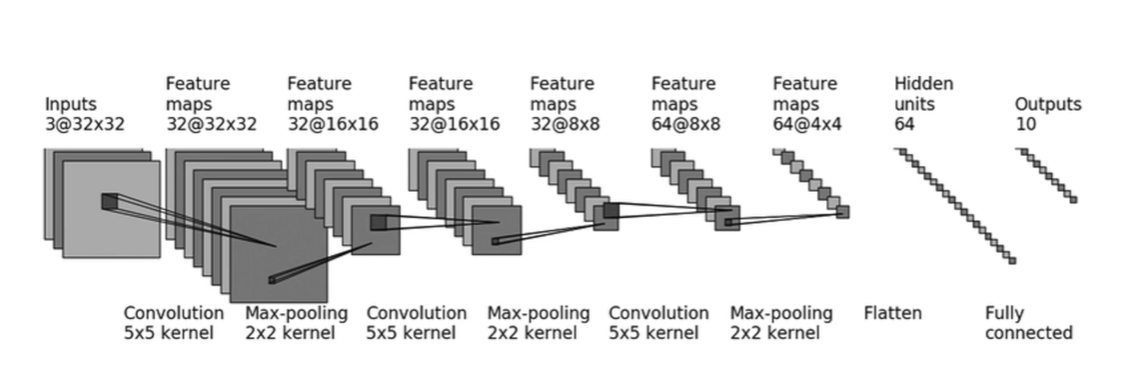

- 不用Sequential：

In [ ]:
class model_init(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.maxpool_1 = nn.MaxPool2d(kernel_size=2)
        self.conv_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.maxpool_2 = nn.MaxPool2d(kernel_size=2)
        self.conv_3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.maxpool_3 = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(in_features=1024, out_features=64)
        self.linear_2 = nn.Linear(in_features=64, out_features=10)

    def forward(self, x): # 不用Sequential的话纯手打很繁琐，还容易错
        x = self.conv_1(x)
        x = self.maxpool_1(x)
        x = self.conv_2(x)
        x = self.maxpool_2(x)
        x = self.conv_3(x)
        x = self.maxpool_3(x)
        x = self.flatten(x)
        x = self.linear_1(x)
        x = self.linear_2(x)
        return x

*same padding：(N+2P-K)/stride +1 = N，得到输入输出的特征图长宽不变，即：stride=1时，P=(K-1)/2*

In [43]:
my_model_init = model_init()
print(my_model_init)

model_init(
  (conv_1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool_3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_1): Linear(in_features=1024, out_features=64, bias=True)
  (linear_2): Linear(in_features=64, out_features=10, bias=True)
)


- 检查设定的参数值有没有错

In [ ]:
input_test = torch.ones((64, 3, 32, 32)) # 用与输入相同形状的全1张量测试
output_test = my_model_init(input_test)
print(output_test.shape)

torch.Size([64, 10])


- 用Sequential：

In [ ]:
class model_seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(in_features=1024, out_features=64),
            nn.Linear(in_features=64, out_features=10),
        )

    def forward(self, x): # 用Sequential简洁很多，不容易出错
        x = self.seq(x)
        return x

In [46]:
my_model_seq = model_seq()

- 检查设定的参数值有没有错

In [48]:
output_test = my_model_seq(input_test)
print(output_test.shape)

torch.Size([64, 10])


- 写入日志

In [50]:
writer = SummaryWriter("logs_seq")

writer.add_graph(my_model_seq, input_test) # writer.add_graph第一个参数为模型，第二个参数为输入

writer.close()

*终端输入：tensorboard --logdir=logs_seq --port=6007，打开tensorboard的graphs，双击点开各个模块查看详细*